**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 05 â€” Data Cleaning & Preprocessing

Text normalization, image standardization, train-set augmentation, and building the final `MemeDataset` class used by all downstream notebooks.

In [53]:
import os
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    default_candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"


def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None


DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["train"])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
TEST_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["test"])
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if TRAIN_PATH is None or DEV_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(f"Expected train/dev/test splits under {DATA_DIR}")

DATA_DIR = str(DATA_DIR)
IMG_DIR = str(IMG_DIR) if IMG_DIR is not None else None
TRAIN_PATH = str(TRAIN_PATH)
DEV_PATH = str(DEV_PATH)
TEST_PATH = str(TEST_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"Device         : {DEVICE}")


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f])


train_raw = load_jsonl(TRAIN_PATH)
dev_raw = load_jsonl(DEV_PATH)
test_raw = load_jsonl(TEST_PATH)
print(f"Loaded: train={len(train_raw)}, dev={len(dev_raw)}, test={len(test_raw)}")

Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
Using source   : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Device         : cuda
Loaded: train=8500, dev=500, test=1000


In [54]:
from pathlib import Path


def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))

    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)

    candidates.extend([
        data_dir / image_ref,
        data_dir.parent / image_ref,
    ])

    if image_ref.parts:
        if image_ref.parts[0] in {"img", "images"} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([
                data_dir / stripped,
                data_dir.parent / stripped,
            ])
        elif image_ref.parts[0] not in {"img", "images"}:
            candidates.extend([
                data_dir / "img" / image_ref,
                data_dir / "images" / image_ref,
                data_dir.parent / "img" / image_ref,
                data_dir.parent / "images" / image_ref,
            ])

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find image '{image_ref}' relative to {data_dir}")

In [55]:
# â”€â”€ 5.1 Text cleaning â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def clean_text(text: str) -> str:
    """Normalize meme text while preserving sentiment-bearing content."""
    if not isinstance(text, str):
        return ""
    text = text.encode("utf-8", errors="ignore").decode("utf-8")  # fix encoding
    text = re.sub(r"https?://\S+", " ", text)                     # remove URLs
    text = re.sub(r"@\w+", " ", text)                             # remove @mentions
    text = re.sub(r"#(\w+)", r" \1 ", text)                       # expand hashtags
    text = re.sub(r"[^\x00-\x7F]+", " ", text)                    # remove non-ASCII
    text = re.sub(r"\s+", " ", text).strip()                      # normalize whitespace
    # Do NOT lowercase â€” CLIP tokenizer handles case; 
    # ALL CAPS often signals emphasis/anger in memes
    return text

# Test
tests = [
    "CHECK THIS OUT https://example.com #hate @someone  DISGUSTING!",
    "  hello   world  ",
    "Caf\u00e9 meme with \u00e9l\u00e8ve symbols",
]
for t in tests:
    print(f"  Before: {repr(t)}")
    print(f"  After : {repr(clean_text(t))}")
    print()

  Before: 'CHECK THIS OUT https://example.com #hate @someone  DISGUSTING!'
  After : 'CHECK THIS OUT hate DISGUSTING!'

  Before: '  hello   world  '
  After : 'hello world'

  Before: 'Café meme with élève symbols'
  After : 'Caf meme with l ve symbols'



In [56]:
# Apply text cleaning to all splits
for df in [train_raw, dev_raw, test_raw]:
    df["clean_text"] = df["text"].apply(clean_text)
    # Fill any remaining empties with a placeholder
    df["clean_text"] = df["clean_text"].replace("", "[no text]").fillna("[no text]")

print("Text cleaning applied.")
print("Before vs after example:")
row = train_raw.sample(1, random_state=42).iloc[0]
print(f"  Original : {row.text}")
print(f"  Cleaned  : {row.clean_text}")

Text cleaning applied.
Before vs after example:
  Original : the latest toy has hit the shops it's a talking muslim doll nobody knows what the fuck its says, because no one has the guts to pull the string
  Cleaned  : the latest toy has hit the shops it's a talking muslim doll nobody knows what the fuck its says, because no one has the guts to pull the string


In [57]:
# â”€â”€ 5.2 Image preprocessing pipelines â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# CLIP expects 224Ã—224 normalized with specific mean/std
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]
IMG_SIZE  = 224

# Training transform â€” with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),   # slightly larger for crop
    transforms.RandomCrop(IMG_SIZE),                      # random crop
    transforms.RandomHorizontalFlip(p=0.3),               # mild flip (meme text can mirror)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
])

# Evaluation transform â€” deterministic
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
])

print("Train transform:", train_transform)
print("\nEval transform:", eval_transform)

Train transform: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.3)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
)

Eval transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
)


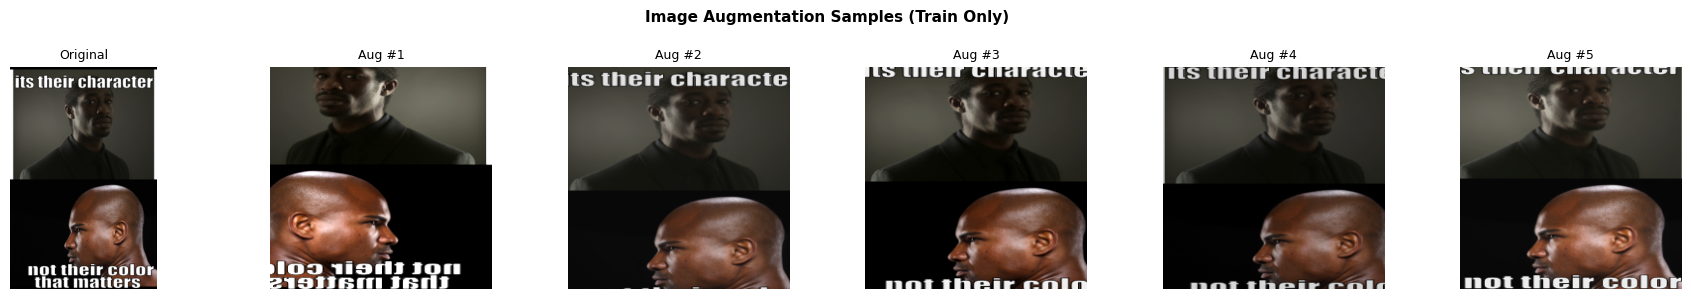

In [58]:
#  5.3 Visualize augmentation effects 
sample_img_path = resolve_image_path(DATA_DIR, train_raw.iloc[0]["img"])
pil_img = Image.open(sample_img_path).convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(pil_img)
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for i in range(1, 6):
    augmented = train_transform(pil_img)
    # Unnormalize for display
    mean = torch.tensor(CLIP_MEAN).view(3, 1, 1)
    std  = torch.tensor(CLIP_STD).view(3, 1, 1)
    display = (augmented * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(display)
    axes[i].set_title(f"Aug #{i}", fontsize=9)
    axes[i].axis("off")

plt.suptitle("Image Augmentation Samples (Train Only)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [59]:
#  5.4 MemeDataset class (self-contained, used in all downstream notebooks) 
class MemeDataset(Dataset):
    """
    Loads hateful memes data. Returns image tensor + tokenized text + label.
    Compatible with CLIP processor (processor handles both image and text).
    """
    def __init__(self, df, data_dir, processor, transform=None, augment=False):
        self.df        = df.reset_index(drop=True)
        self.data_dir  = data_dir
        self.processor = processor
        self.transform = transform
        self.augment   = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img_path = resolve_image_path(self.data_dir, row["img"])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (224, 224), color=(128, 128, 128))

        # Use clean_text if available, else text
        text = str(row.get("clean_text", row["text"]))

        if self.augment and self.transform is not None:
            image = self.transform(image)
            return {
                "pixel_values": image,
                "text": text,
                "label": torch.tensor(int(row["label"]), dtype=torch.long),
            }

        encoding = self.processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77,
        )
        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
        }

In [60]:
# â”€â”€ 5.5 Test MemeDataset with CLIP processor â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

test_ds = MemeDataset(train_raw.head(5), DATA_DIR, processor)
sample  = test_ds[0]

print("Sample batch keys:", list(sample.keys()))
print(f"  pixel_values shape : {sample['pixel_values'].shape}")
print(f"  input_ids shape    : {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label              : {sample['label']}")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Sample batch keys: ['pixel_values', 'input_ids', 'attention_mask', 'label']
  pixel_values shape : torch.Size([3, 224, 224])
  input_ids shape    : torch.Size([77])
  attention_mask shape: torch.Size([77])
  label              : 0


In [61]:
# â”€â”€ 5.6 Label balancing strategy â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from torch.utils.data import WeightedRandomSampler

labels  = train_raw["label"].values
n_total = len(labels)
n_hat   = (labels == 1).sum()
n_ben   = (labels == 0).sum()

# Per-sample weight: inverse class frequency
class_weights  = {0: n_total / (2.0 * n_ben), 1: n_total / (2.0 * n_hat)}
sample_weights = [class_weights[l] for l in labels]
print(f"Class weights: non-hateful={class_weights[0]:.3f}, hateful={class_weights[1]:.3f}")

# WeightedRandomSampler for DataLoader
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
print("WeightedRandomSampler ready â€” ensures ~50/50 batches.")

# Illustrate: simulate 1000 draws
import random
drawn = random.choices([0, 1], weights=[class_weights[0], class_weights[1]], k=1000)
print(f"Simulated batch distribution (1000 draws): 0={drawn.count(0)}, 1={drawn.count(1)}")

Class weights: non-hateful=0.780, hateful=1.393
WeightedRandomSampler ready â€” ensures ~50/50 batches.
Simulated batch distribution (1000 draws): 0=346, 1=654


In [62]:
# â”€â”€ 5.7 Save cleaned splits for downstream notebooks â”€â”€â”€â”€â”€â”€â”€â”€â”€
for name, df in [("train", train_raw), ("dev", dev_raw), ("test", test_raw)]:
    out = df[["id", "img", "label", "text", "clean_text"]].copy() if "label" in df.columns \
          else df[["id", "img", "text", "clean_text"]].copy()
    path = os.path.join(OUTPUT_DIR, f"{name}_clean.jsonl")
    out.to_json(path, orient="records", lines=True)
    print(f"Saved {path}  ({len(out)} rows)")

print("\nPreprocessing complete. Proceed to notebook 06 (Baselines).")

Saved /kaggle/working/train_clean.jsonl  (8500 rows)
Saved /kaggle/working/dev_clean.jsonl  (500 rows)
Saved /kaggle/working/test_clean.jsonl  (1000 rows)

Preprocessing complete. Proceed to notebook 06 (Baselines).
